In [1]:
from occultence import *
import occultence
occultence.version()

'0.5.0'

nr of measurements: 1906


(0.99, 1.015)

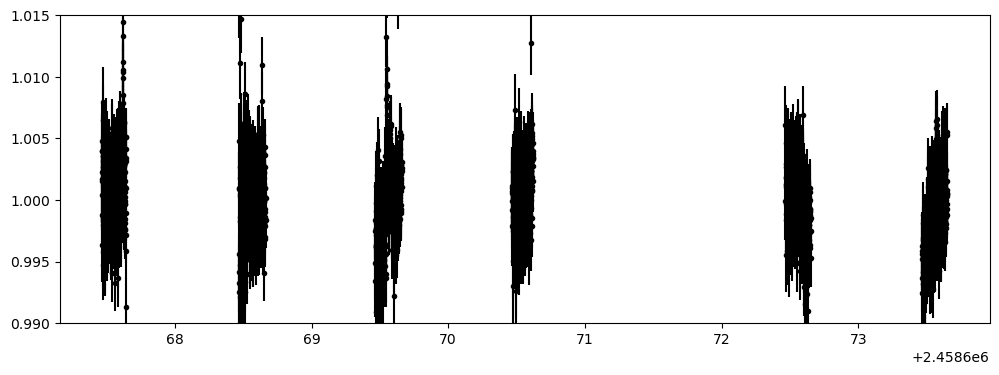

In [13]:
test_case = False
pre_bin = False


if test_case:

    t = list(np.linspace(0.5,0.9,200))
    daylength = len(t)
    ndays = 10
    gap = 16/24.
    A = 0.005
    
    for d in range(1,ndays):
        t.extend(np.array(t[:daylength]) + d * (1 + gap))
    
    t = np.array(t)
    ferr = 1e-3 * np.ones(len(t))
    sinusoid_trend = A * np.sin(t)
    f = 1 + sinusoid_trend + (ferr * (np.random.randn(len(t))))
    f[22] = 1.01 # add a cosmic
    f[63] = 1.008 # add a cosmic
    f[50] = 0.0 # add a zero flux point

else:
    file_path = "/Users/fl386/Desktop/SPECULOOS_project/zooniverse/data"
    files = glob.glob(file_path+"/*")

    i = 90
    file_name = files[i]
    
    gaia_id = file_name.split("/")[-1].replace(".csv","")

    data = pd.read_csv(file_name)

    mask = (~np.isnan(data["diff_flux_use"])) & (~np.isnan(data["diff_error"])) & (data["diff_error"]>0)
    data = data[mask]
    data.reset_index(drop = True, inplace = True)

    t = data["bjd"].values
    f = data["diff_flux_use"].values
    ferr = data["diff_error"].values
    
    print(f"nr of measurements: {len(t)}")
    if pre_bin:
        #0.005*24.*60. = 7 minutes
        #some problem if 7 mins or greater (with smaller_binning, problem with units in astropy)
        blc = binning(t, f, bins=0.01, error=ferr, std=True)
        t,f,ferr = blc
        print(f"nr of measurements after binning: {len(t)}")



# f *= np.linspace(1,1.01, len(t)) # add a linear trend for the GP to remove
plt.figure(figsize=(12,4))
plt.errorbar(t,f,ferr,fmt='k.')
plt.ylim(0.99,1.015)

In [14]:
targ = LightCurve(name = "test",
                  time = t,
                  flux = f,
                  uncertainty = np.abs(ferr),
                  metadata={'R_star':0.1*u.R_sun, 'M_star':0.1*u.M_sun})

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='Flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time [d]'>], dtype=object)

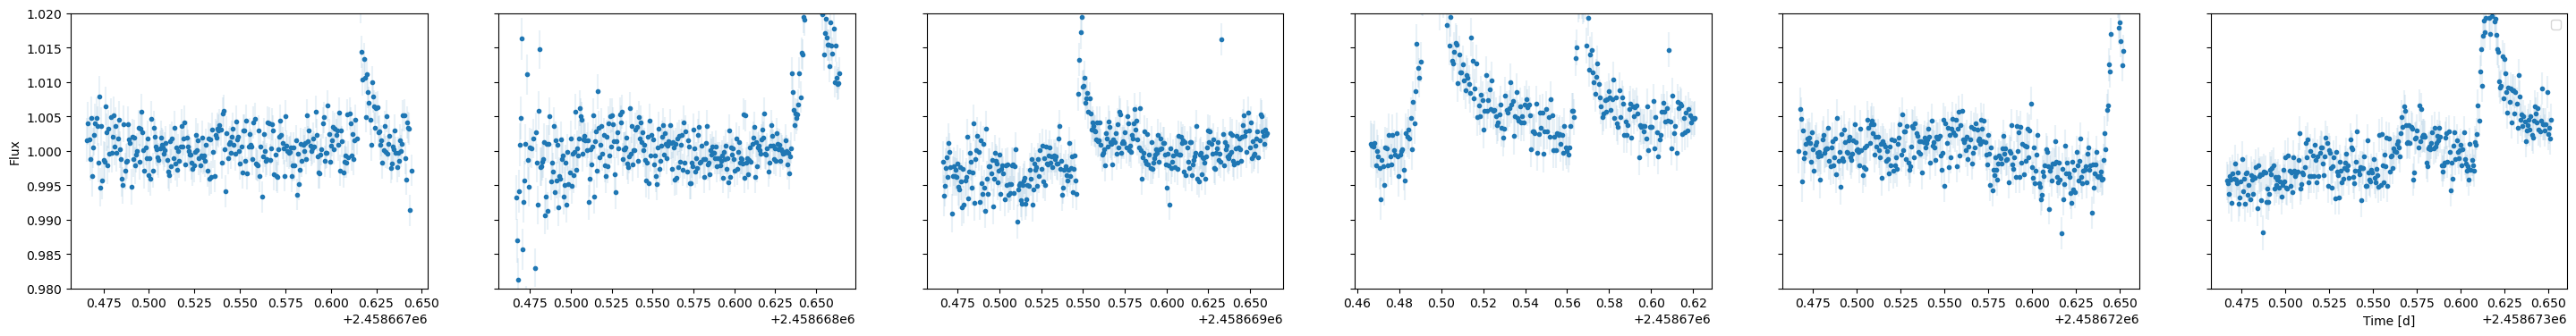

In [15]:
flare_lc = targ.inject_flares(nfake=5, amp_range=[1e-3, 0.05])
flare_lc.plot()

In [16]:
flare_lc.metadata

{'name': 'test_injectedflares',
 'target': 'test',
 'R_star': <Quantity 0.1 solRad>,
 'M_star': <Quantity 0.1 solMass>,
 'flares_injected': {'nflares_injected': 5,
  'flare_params': {'t0': [2458673.615204471,
    2458670.494347201,
    2458672.6465143845,
    2458670.5662640166,
    2458668.6458511124],
   'fwhm': [0.010998258781248705,
    0.011609738900173187,
    0.007765247255511324,
    0.006097801806449588,
    0.011216003114777082],
   'amp': [0.02337169885598492,
    0.043036338330259896,
    0.03263278272100627,
    0.025020995272652877,
    0.044023046235716054]}}}

In [17]:
clip_lc = flare_lc.global_and_local_sigma_clip(global_sc_kw={'nsigma_upper':5, 'nsigma_lower':5},
                                    local_sc_kw={'nsigma_upper':3, 'nsigma_lower':np.inf, 'running_mean_boxsize':0.4})

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='Flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time [d]'>], dtype=object)

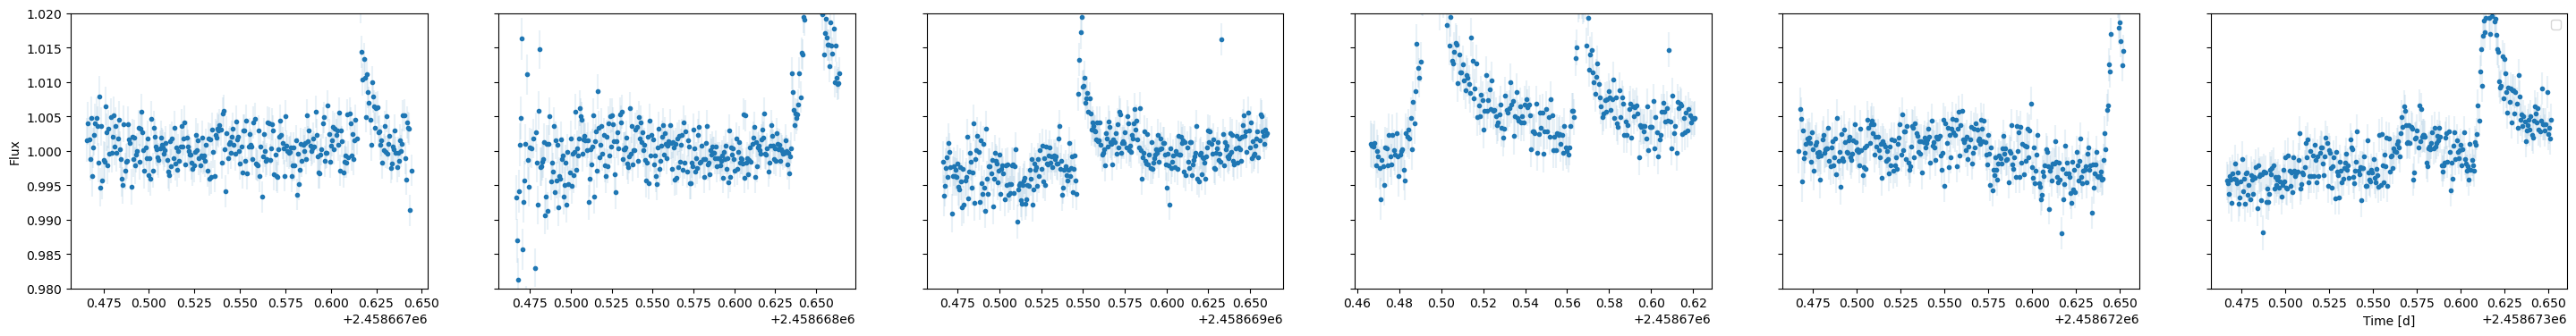

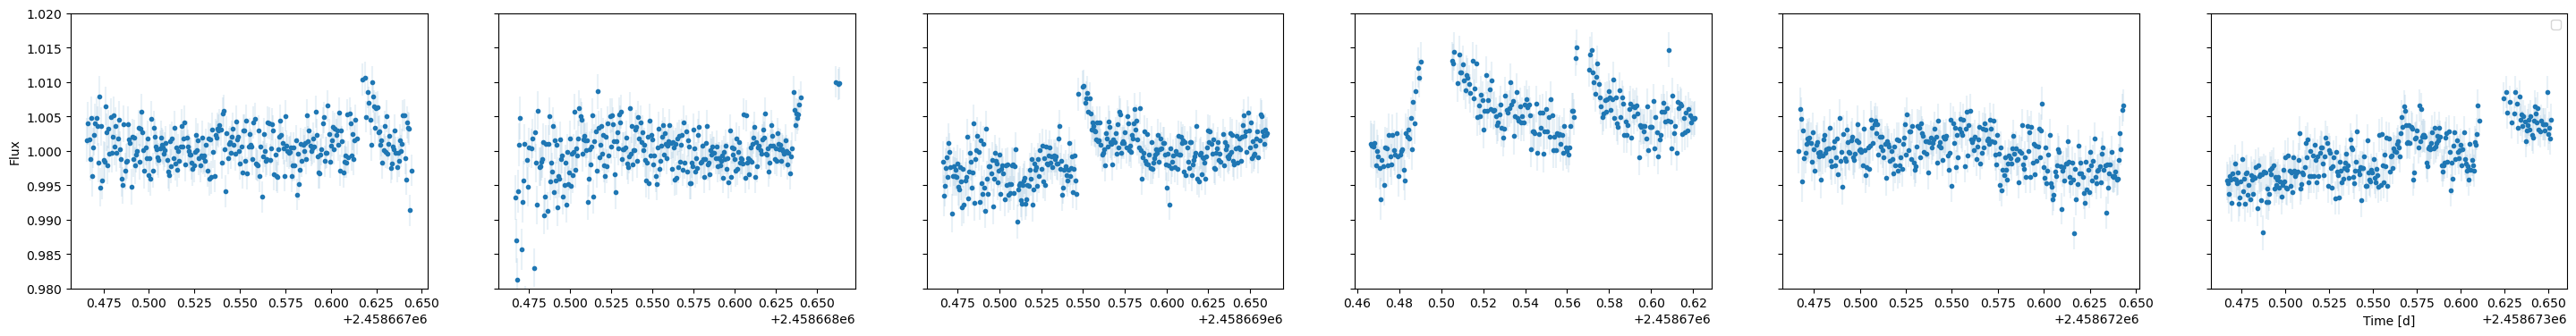

In [18]:
flare_lc.plot()
clip_lc.plot()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


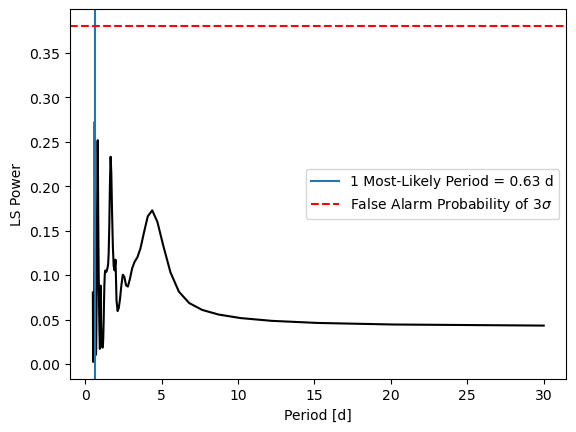

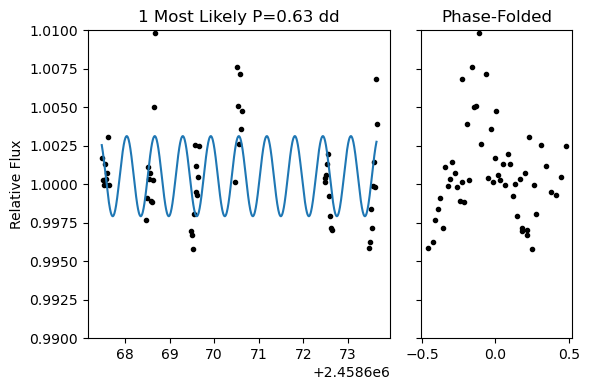

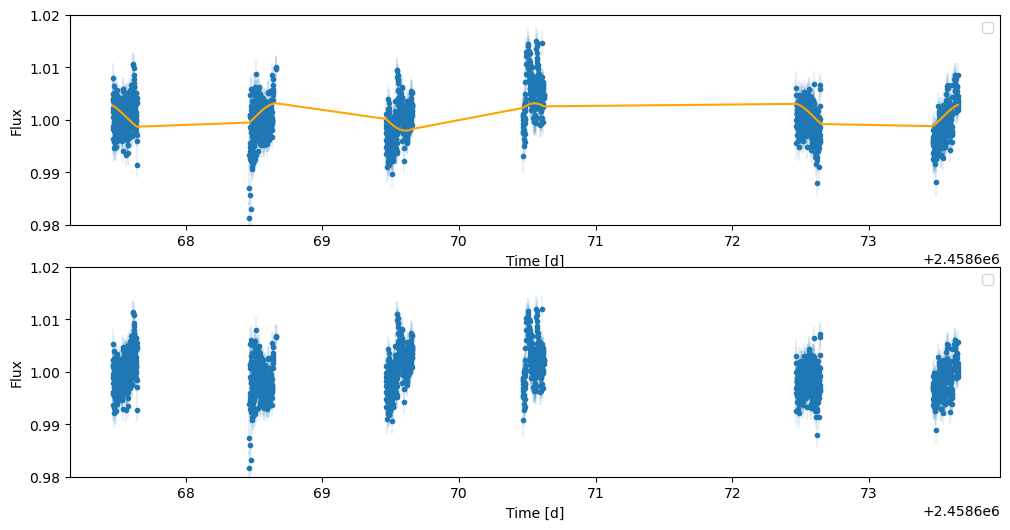

In [19]:
detrended_targ = clip_lc.lombscargle_detrend(plot=True, ls_binning=30*u.minute,
                                  minimum_frequency=1/(30*u.d),
                                  maximum_frequency=1/(0.5*u.d),
                                  samples_per_peak=10,
                                  npeaks=1,
                                  nsigma=3)

In [20]:
flare_lc_detrended = flare_lc._create_copy()
flare_lc_detrended.timelike['flux'] = flare_lc_detrended.timelike['flux']/detrended_targ.timelike['ls_model']

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


There are 7 flare candidates with >5.0 min over 3$\sigma$


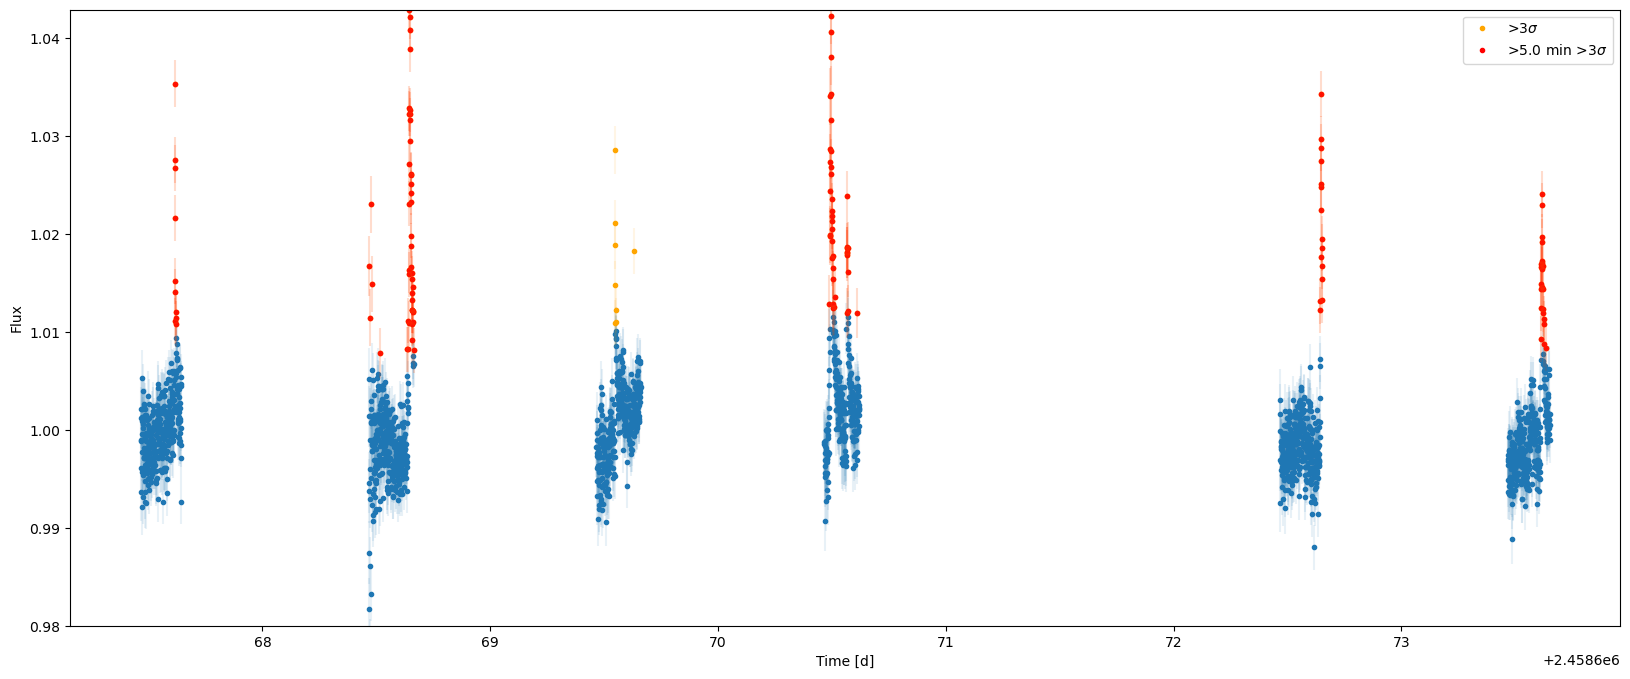

In [21]:
flares_masked = flare_lc_detrended.detect_flares_sclip(plot=True, min_flare_separation=60*u.minute)

In [22]:
flares_masked.metadata

{'name': 'test_injectedflares_sigmaclipped_flaresremoved',
 'target': 'test',
 'R_star': <Quantity 0.1 solRad>,
 'M_star': <Quantity 0.1 solMass>,
 'flares_injected': {'nflares_injected': 5,
  'flare_params': {'t0': [2458673.615204471,
    2458670.494347201,
    2458672.6465143845,
    2458670.5662640166,
    2458668.6458511124],
   'fwhm': [0.010998258781248705,
    0.011609738900173187,
    0.007765247255511324,
    0.006097801806449588,
    0.011216003114777082],
   'amp': [0.02337169885598492,
    0.043036338330259896,
    0.03263278272100627,
    0.025020995272652877,
    0.044023046235716054]}},
 'flares_detected': {'nflares': 7,
  'threshold_duration': <Quantity 5. min>,
  'flare_regions': [[263, 277],
   [316, 404],
   [609, 659],
   [1035, 1080],
   [1166, 1242],
   [1570, 1584],
   [1835, 1873]],
  'threshold_sigma': 3}}

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='Flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time [d]'>], dtype=object)

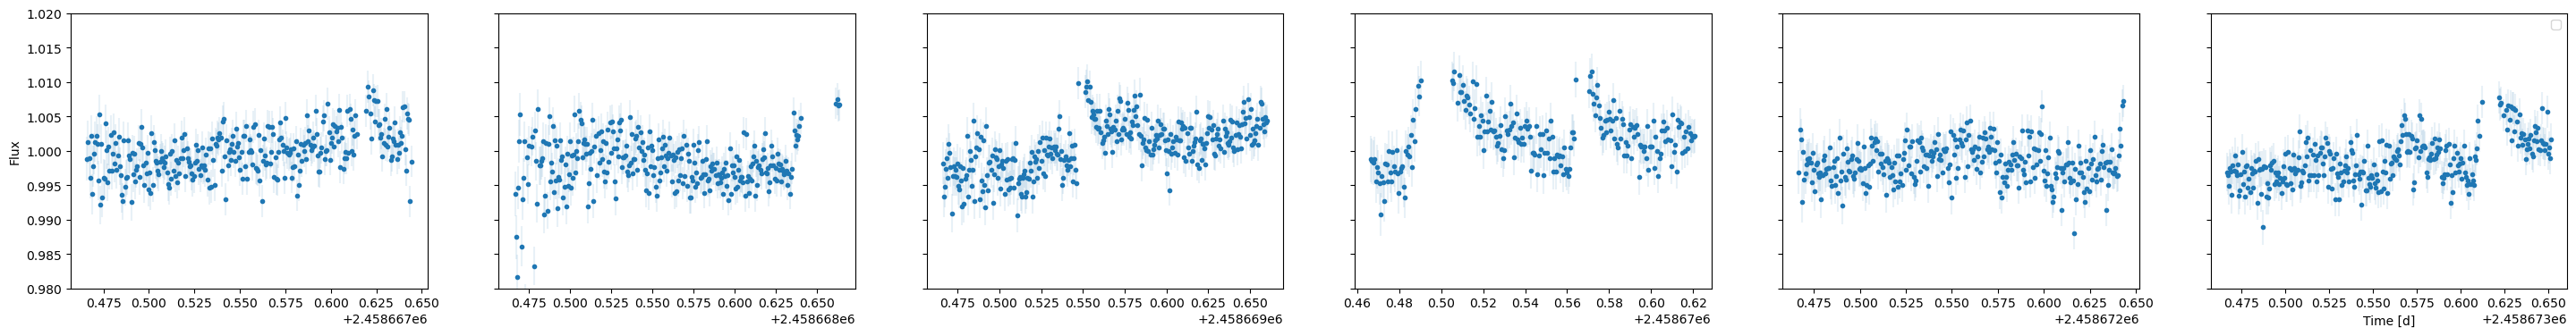

In [23]:
flares_masked.plot()